# Environment

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['BLIS_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'

In [3]:
from importlib import reload
import sys
sys.path.append("../..") # LC-NICER/
import medi_ai
import pandas as pd
import copy
import yaml
from datetime import datetime
from pathlib import Path
import pickle
import numpy as np

In [4]:
def load_settings():
    return yaml.load(open("task.yaml", "r"), Loader=yaml.FullLoader)

def reload_medi_ai():
    import sys
    from importlib import reload
    for module in list(sys.modules):
        if module.startswith('medi_ai'):
            reload(sys.modules[module])
    for module in list(sys.modules):
        if module.startswith('medi_ai'):
            reload(sys.modules[module])

def reload_all():
    global task_settings
    reload(medi_ai)
    reload_medi_ai()
    task_settings = load_settings()

# Settings

In [5]:
task_settings = load_settings()
output_dir = Path("output") / task_settings["Task_Name"]
print("=> Output directory:", output_dir)

=> Output directory: output/test


# LoadData
In this step, we load the dataset from data.csv file.
The data contains patient information with the following structure:
- `ID`: Unique identifier for each scan (e.g., demo_pre_P1)
- `PID`: Patient identifier (e.g., P1, P2)
- `phase`: Scan phase (pre or post treatment)
- `image_path`: Path to the CT image file
- `mask_path`: Path to the corresponding mask file

In [6]:
load_state = dict(Step="LoadData", Datasets=copy.deepcopy(task_settings["Datasets"]))

# HI


## Step 1: Preprocessing

**Settings from task.yaml:**
- `use_multiprocessing`: true - Enables parallel processing for faster execution
- `Pipeline`: A sequential pipeline with two preprocessing steps:
  - `resample` - Resamples the images to standard resolution

This preprocessing stage prepares the CT images for subsequent analysis by standardizing their resolution and correcting for intensity artifacts.


In [7]:
prep_state = medi_ai.call.run_step("Preprocessing", task_settings, load_state, output_dir)

Running resample...
=> Dataset: lung (n=4)


resample:   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


resample: 100%|██████████| 4/4 [01:18<00:00, 19.69s/it, demo_post_P2_3 is finished]


## Step 2: VariousMask

**Settings from task.yaml:**
- `use_multiprocessing`: true - Enables parallel processing for faster execution
- `CopyImages`: true - Copies original images to the output directory instead of creating symlinks to avoid potential errors
- `KernelSizes`: [3, 5, 7] - Applies three different kernel sizes for mask processing
- `MaskTypes`: ["tumor", "peritumor"] - Generates both tumor and peritumoral region masks


In [8]:
varm_state = medi_ai.call.run_step("VariousMask", task_settings, prep_state, output_dir)

=> Dataset: lung (n=4)


VariousMask (lung):   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


VariousMask (lung): 100%|██████████| 4/4 [01:27<00:00, 21.81s/it, demo_post_P2_3 is finished]



## Step 3: PreSegmentation

**Settings from task.yaml:**
- `use_multiprocessing`: true - Enables parallel processing for faster execution
- `max_workers`: null - Uses the default number of workers (system-dependent)
- `CopyImages`: true - Creates actual copies of images instead of symbolic links
- `SVMaxParts`: 100 - Maximum number of supervoxel parts to generate
- `EachSVMinPixels`: 343 - Minimum pixel count for each supervoxel (equivalent to 7×7×7 cube)


In [9]:
seg_state = medi_ai.call.run_step("PreSegmentation", task_settings, varm_state, output_dir)

=> Dataset: peritumor#3#lung (n=4)


PreSegmentation (peritumor#3#lung):   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


PreSegmentation (peritumor#3#lung): 100%|██████████| 4/4 [03:00<00:00, 45.20s/it, demo_pre_P2_2 is finished] 


=> Dataset: peritumor#5#lung (n=4)


...

PreSegmentation (peritumor#7#lung): 100%|██████████| 4/4 [03:44<00:00, 56.07s/it, demo_post_P2_3 is finished]


=> Dataset: tumor#lung (n=4)


PreSegmentation (tumor#lung):   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


PreSegmentation (tumor#lung): 100%|██████████| 4/4 [02:26<00:00, 36.64s/it, demo_pre_P2_2 is finished] 


## Step 4: SV-based Feature

**Radiomics Feature Extraction (FeatureExtraction#SV)**  
Settings from task.yaml:
- `use_multiprocessing`: false - Serial processing instead of parallel
- `parallel_type`: "process" - Would use process-based parallelism if enabled
- `params`: Uses configuration from "../../configs/feature_extraction/CT_tumor_he.yaml"
- `skip_errors`: true - Continues processing even if errors occur during feature extraction

**Deep Learning Feature Extraction (DeepLearningFeatureExtraction#SV)**  
Settings from task.yaml:
- Uses the MAE3D (Masked Autoencoder 3D) model trained on lung CT data
- Model configuration path: "../../configs/dl_feature_extraction/mae3d_lung_CT"


In [10]:
sv_fe_state = medi_ai.call.run_step("FeatureExtraction#SV", task_settings, seg_state, output_dir)
sv_dl_state = medi_ai.call.run_step("DeepLearningFeatureExtraction#SV", task_settings, seg_state, output_dir)

[FeatureExtraction] => skip errors
=> Dataset: peritumor#3#lung (n=216)


extract_radiomics_features: 100%|██████████| 216/216 [00:08<00:00, 25.50it/s, demo_post_P2_215 is processing]


=> Dataset: peritumor#5#lung (n=277)


extract_radiomics_features: 100%|██████████| 277/277 [00:11<00:00, 24.87it/s, demo_post_P2_276 is processing]


=> Dataset: peritumor#7#lung (n=324)


...

Command executed successfully
Output: output/test/DeepLearningFeatureExtraction#SV/peritumor#5#lung.csv

=> Dataset: peritumor#7#lung (n=324)
Command: cd /media/wzt/wdc18t/wzt/src/LC-NICER/configs/dl_feature_extraction/mae3d_lung_CT; python -u main.py --src_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/PreSegmentation/peritumor#7#lung/peritumor#7.csv" --base_dir "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/PreSegmentation/peritumor#7#lung" --dst_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/DeepLearningFeatureExtraction#SV/peritumor#7#lung.csv"
_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=['fc_norm.weight', 'fc_norm.bias'])
cuda


100%|██████████| 324/324 [00:04<00:00, 64.83it/s]


Command executed successfully
Output: output/test/DeepLearningFeatureExtraction#SV/peritumor#7#lung.csv

=> Dataset: tumor#lung (n=171)
Command: cd /media/wzt/wdc18t/wzt/src/LC-NICER/configs/dl_feature_extraction/mae3d_lung_CT; python -u main.py --src_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/PreSegmentation/tumor#lung/tumor.csv" --base_dir "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/PreSegmentation/tumor#lung" --dst_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/DeepLearningFeatureExtraction#SV/tumor#lung.csv"
_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=['fc_norm.weight', 'fc_norm.bias'])
cuda


100%|██████████| 171/171 [00:02<00:00, 63.78it/s]


Command executed successfully
Output: output/test/DeepLearningFeatureExtraction#SV/tumor#lung.csv



**SV-based Radiomics + Deep Learning Feature Fusion (FeatureFusion#SV-Rad+DL)**  
Settings from task.yaml:
- `method`: concat - Concatenates features from different sources into a single feature vector
- `column_names`: ["{old_name}", "{old_name}"] - Preserves original feature names in the concatenated feature set

In [11]:
sv_ff_state = medi_ai.call.run_step(
    "FeatureFusion#SV-Rad+DL", 
    task_settings, 
    dict(Datasets=pd.DataFrame([sv_fe_state, sv_dl_state])["Datasets"].values.tolist()), 
    output_dir)


**Normalization (Normalization#01)**

Settings from task.yaml:
- `method`: MinMaxScaler - Transforms features by scaling each feature to a specified range, typically [0, 1]
- `reference`: null - No external reference dataset is used for scaling parameters
- `pickle`: Specifies saved normalization models for different regions
  - `peritumor#3#lung`: pkl/Normalization#01/peritumor#3#lung#Rad+DL.pkl
  - `peritumor#5#lung`: pkl/Normalization#01/peritumor#5#lung#Rad+DL.pkl
  - `peritumor#7#lung`: pkl/Normalization#01/peritumor#7#lung#Rad+DL.pkl
  - `tumor#lung`: pkl/Normalization#01/tumor#lung#Rad+DL.pkl


In [12]:
sv_ff_norm_state = medi_ai.call.run_step("Normalization#01", task_settings, sv_ff_state, output_dir)

Running normalization with MinMaxScaler
=> No reference dataset, fit on all datasets



## Step 5: SubRegion Clustering (SV → SR)

**SubRegion Clustering Settings**  
Settings from task.yaml:
- `use_multiprocessing`: true - Enables parallel processing for improved performance
- `CopyImages`: true - Copies original images to output directory instead of creating symlinks
- **Prediction Configuration**:
  - Uses pre-trained clustering models for different regions:
    - `peritumor#3#lung`: pkl/SubRegionClustering/peritumor#3#lung#Rad+DL.pkl
    - `peritumor#5#lung`: pkl/SubRegionClustering/peritumor#5#lung#Rad+DL.pkl
    - `peritumor#7#lung`: pkl/SubRegionClustering/peritumor#7#lung#Rad+DL.pkl
    - `tumor#lung`: pkl/SubRegionClustering/tumor#lung#Rad+DL.pkl


In [13]:
sv_ff_norm_state["image_src_dir"] = seg_state["Step"]
sr_state = medi_ai.call.run_step("SubRegionClustering", task_settings, sv_ff_norm_state, output_dir)

{'peritumor#3#lung': {'type': 'testing', 'path': 'output/test/Normalization#01/peritumor#3#lung.csv'}, 'peritumor#5#lung': {'type': 'testing', 'path': 'output/test/Normalization#01/peritumor#5#lung.csv'}, 'peritumor#7#lung': {'type': 'testing', 'path': 'output/test/Normalization#01/peritumor#7#lung.csv'}, 'tumor#lung': {'type': 'testing', 'path': 'output/test/Normalization#01/tumor#lung.csv'}}
{'peritumor#3#lung': 'pkl/SubRegionClustering/peritumor#3#lung#Rad+DL.pkl', 'peritumor#5#lung': 'pkl/SubRegionClustering/peritumor#5#lung#Rad+DL.pkl', 'peritumor#7#lung': 'pkl/SubRegionClustering/peritumor#7#lung#Rad+DL.pkl', 'tumor#lung': 'pkl/SubRegionClustering/tumor#lung#Rad+DL.pkl'}
Loading model from pkl/SubRegionClustering/peritumor#3#lung#Rad+DL.pkl
Start predicting...
Predicting finished in 0.03s
output/test/PreSegmentation/peritumor#3#lung
Start generating subregions...


SubRegionClustering (peritumor#3#lung):   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


SubRegionClustering (peritumor#3#lung): 100%|██████████| 4/4 [00:10<00:00,  2.71s/it, demo_pre_P2_3 is finished] 


Subregions generated in 11.11s
{'peritumor#3#lung': 'pkl/SubRegionClustering/peritumor#3#lung#Rad+DL.pkl', 'peritumor#5#lung': 'pkl/SubRegionClustering/peritumor#5#lung#Rad+DL.pkl', 'peritumor#7#lung': 'pkl/SubRegionClustering/peritumor#7#lung#Rad+DL.pkl', 'tumor#lung': 'pkl/SubRegionClustering/tumor#lung#Rad+DL.pkl'}
Loading model from pkl/SubRegionClustering/peritumor#5#lung#Rad+DL.pkl
Start predicting...
Predicting finished in 0.04s
output/test/PreSegmentation/peritumor#5#lung
Start generating subregions...


...

Subregions generated in 15.76s
{'peritumor#3#lung': 'pkl/SubRegionClustering/peritumor#3#lung#Rad+DL.pkl', 'peritumor#5#lung': 'pkl/SubRegionClustering/peritumor#5#lung#Rad+DL.pkl', 'peritumor#7#lung': 'pkl/SubRegionClustering/peritumor#7#lung#Rad+DL.pkl', 'tumor#lung': 'pkl/SubRegionClustering/tumor#lung#Rad+DL.pkl'}
Loading model from pkl/SubRegionClustering/tumor#lung#Rad+DL.pkl
Start predicting...
Predicting finished in 0.03s
output/test/PreSegmentation/tumor#lung
Start generating subregions...


SubRegionClustering (tumor#lung):   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


SubRegionClustering (tumor#lung): 100%|██████████| 4/4 [00:11<00:00,  2.78s/it, demo_pre_P2_3 is finished] 


Subregions generated in 11.38s



## Step 6: SR-based Feature

**Radiomics Feature Extraction (FeatureExtraction#SR)**  
Settings from task.yaml:
- `use_multiprocessing`: true - Enables parallel processing
- `parallel_type`: "process" - Uses process-based parallelism
- `params`: Uses configuration from "../../configs/feature_extraction/CT_tumor_he.yaml"
- `skip_errors`: true - Continues processing even if errors occur during feature extraction

**Deep Learning Feature Extraction (DeepLearningFeatureExtraction#SR)**  
Settings from task.yaml:
- Uses the MAE3D (Masked Autoencoder 3D) model trained on lung CT data
- Model configuration path: "../../configs/dl_feature_extraction/mae3d_lung_CT"


In [14]:
sr_fe_state = medi_ai.call.run_step("FeatureExtraction#SR", task_settings, sr_state, output_dir)
sr_dl_state = medi_ai.call.run_step("DeepLearningFeatureExtraction#SR", task_settings, sr_state, output_dir)

[FeatureExtraction] => skip errors
=> Dataset: peritumor#3#lung (n=18)


Extracting radiomics features:   0%|          | 0/18 [00:00<?, ?it/s]


=> futures: 18


Extracting radiomics features: 100%|██████████| 18/18 [00:00<00:00, 21.16it/s, demo_pre_P1_12 is finished]


=> Dataset: peritumor#5#lung (n=19)


...

Command executed successfully
Output: output/test/DeepLearningFeatureExtraction#SR/peritumor#5#lung.csv

=> Dataset: peritumor#7#lung (n=20)
Command: cd /media/wzt/wdc18t/wzt/src/LC-NICER/configs/dl_feature_extraction/mae3d_lung_CT; python -u main.py --src_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/SubRegionClustering/peritumor#7#lung/peritumor#7#lung.csv" --base_dir "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/SubRegionClustering/peritumor#7#lung" --dst_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/DeepLearningFeatureExtraction#SR/peritumor#7#lung.csv"
_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=['fc_norm.weight', 'fc_norm.bias'])
cuda


100%|██████████| 20/20 [00:00<00:00, 42.60it/s]


Command executed successfully
Output: output/test/DeepLearningFeatureExtraction#SR/peritumor#7#lung.csv

=> Dataset: tumor#lung (n=16)
Command: cd /media/wzt/wdc18t/wzt/src/LC-NICER/configs/dl_feature_extraction/mae3d_lung_CT; python -u main.py --src_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/SubRegionClustering/tumor#lung/tumor#lung.csv" --base_dir "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/SubRegionClustering/tumor#lung" --dst_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/DeepLearningFeatureExtraction#SR/tumor#lung.csv"
_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=['fc_norm.weight', 'fc_norm.bias'])
cuda


100%|██████████| 16/16 [00:00<00:00, 41.30it/s]


Command executed successfully
Output: output/test/DeepLearningFeatureExtraction#SR/tumor#lung.csv



**SR-based Radiomics + Deep Learning Feature Fusion (FeatureFusion#SR-Rad+DL)**
Settings from task.yaml:
- `method`: concat - Concatenates features from different sources into a single feature vector
- `column_names`: ["{old_name}", "{old_name}"] - Preserves original feature names in the concatenated feature set

In [15]:
sr_ff_state = medi_ai.call.run_step(
    "FeatureFusion#SR-Rad+DL", 
    task_settings, 
    dict(Datasets=pd.DataFrame([sr_fe_state, sr_dl_state])["Datasets"].values.tolist()), 
    output_dir)


## Step 7: TumorHeterogeneity

**Settings from task.yaml:**
- Uses pre-trained prediction models for heterogeneity analysis
- `predict.pickle_dir`: Contains model paths for different ROI types
  - `peritumor#3#lung`: Model for peritumoral region with 3mm kernel (path: `pkl/TumorHeterogeneity/peritumor#3#lung#Rad+DL#Rad+DL`)
  - `peritumor#5#lung`: Model for peritumoral region with 5mm kernel (path: `pkl/TumorHeterogeneity/peritumor#5#lung#Rad+DL#Rad+DL`)
  - `peritumor#7#lung`: Model for peritumoral region with 7mm kernel (path: `pkl/TumorHeterogeneity/peritumor#7#lung#Rad+DL#Rad+DL`)
  - `tumor#lung`: Model for tumor region (path: `pkl/TumorHeterogeneity/tumor#lung#Rad+DL#Rad+DL`)


In [16]:
th_state = medi_ai.call.run_step("TumorHeterogeneity", task_settings, sr_ff_state, output_dir)

Predicting TumorHeterogeneity...
{'peritumor#3#lung': {'type': 'testing', 'path': 'output/test/FeatureFusion#SR-Rad+DL/peritumor#3#lung.csv'}, 'peritumor#5#lung': {'type': 'testing', 'path': 'output/test/FeatureFusion#SR-Rad+DL/peritumor#5#lung.csv'}, 'peritumor#7#lung': {'type': 'testing', 'path': 'output/test/FeatureFusion#SR-Rad+DL/peritumor#7#lung.csv'}, 'tumor#lung': {'type': 'testing', 'path': 'output/test/FeatureFusion#SR-Rad+DL/tumor#lung.csv'}}
=> Dataset: peritumor#3#lung (n=18)
=> Dataset: peritumor#5#lung (n=19)
=> Dataset: peritumor#7#lung (n=20)
=> Dataset: tumor#lung (n=16)


In [17]:
og_df = pd.read_csv(load_state["Datasets"]["lung"]["path"], dtype={"ID": str})
for ds in th_state["Datasets"].values():
    path = ds["path"]
    df = pd.read_csv(path, dtype={"ID": str})
    merged_df = og_df.merge(df, on="ID", how="left", indicator=True)
    merged_df.insert(1, "OK", merged_df.pop("_merge").astype(str))
    merged_df["OK"] = merged_df["OK"].apply(lambda x: "OK" if x == "both" else "fillna")
    
    merged_df.fillna(0.0, inplace=True)
    merged_df["#EC#"] = None

    for i in range(1, 6):
        merged_df.rename(columns={f"SR_{i}": f"HI_{i}"}, inplace=True)

    dst_csv_path = output_dir / "TumorHeterogeneityFillNA" / Path(path).name
    dst_csv_path.parent.mkdir(exist_ok=True, parents=True)
    merged_df.to_csv(dst_csv_path, index=False)

## Step 8: Delta Feature

Calculate delta feature

In [18]:
hi_dfs = {
    "peritumor3": pd.read_csv(f"{output_dir}/TumorHeterogeneityFillNA/peritumor#3#lung.csv"),
    "peritumor5": pd.read_csv(f"{output_dir}/TumorHeterogeneityFillNA/peritumor#5#lung.csv"),
    "peritumor7": pd.read_csv(f"{output_dir}/TumorHeterogeneityFillNA/peritumor#7#lung.csv"),
    "tumor": pd.read_csv(f"{output_dir}/TumorHeterogeneityFillNA/tumor#lung.csv"),
}

for type_ in hi_dfs.keys():
    hi_cols = hi_dfs[type_].columns[hi_dfs[type_].columns.get_loc("#EC#")+1:]
    df = hi_dfs[type_].copy()
    df["ID2"] = df["ID"].apply(lambda x: x.replace("pre", "xxx").replace("post", "xxx"))

    # calculate delta
    post_df = df.query("`phase` == 'post'").copy().reset_index(drop=True)
    pre_df = df.query("`phase` == 'pre'").copy().reset_index(drop=True)
    assert post_df[["ID2"]].equals(pre_df[["ID2"]])

    pre_feat = pre_df.loc[:, hi_cols].values
    post_feat = post_df.loc[:, hi_cols].values
    delta_feat = (pre_feat - post_feat) / (pre_feat + 1e-6)

    delta_df = pre_df.copy()
    delta_df.loc[:, hi_cols] = delta_feat
    delta_df["ID"] = delta_df["ID"].apply(lambda x: x.replace("pre", "delta"))
    delta_df["phase"] = "delta"

    df = pd.concat([
        pre_df,
        post_df,
        delta_df
    ], axis=0).reset_index(drop=True)
    df.drop(columns=["ID2"], inplace=True)
    
    # df = df[["ID", "ID2", "center", "phase", "#EC#"] + feat_df.columns.tolist()]
    hi_dfs[type_] = df.copy()

for type_ in hi_dfs.keys():
    print(type_)
    display(hi_dfs[type_])
    (output_dir / "FinalFeature").mkdir(exist_ok=True, parents=True)
    hi_dfs[type_].to_csv(f"{output_dir}/FinalFeature/HI_{type_}.csv", index=False)

peritumor3


,ID,OK,PID,phase,image_path,mask_path,#EC#,HI_1,HI_2,HI_3,HI_4,HI_5
0,demo_pre_P1,OK,P1,pre,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,3.602416,1.679306,-2.513516,0.033358,2.365635
1,demo_pre_P2,OK,P2,pre,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,-4.957699,-2.201730,-1.807936,-14.979872,-9.452949
2,demo_post_P1,OK,P1,post,image/T5179839.nii.gz,mask/T5179839.nii.gz,NaN,7.817591,3.259389,-13.717753,-22.243657,-14.517198
3,demo_post_P2,OK,P2,post,image/DT192542.nii.gz,mask/DT192542.nii.gz,NaN,17.171672,0.000000,0.000000,-4.498825,-7.721307
4,demo_delta_P1,OK,P1,delta,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,-1.170097,-0.940913,-4.457596,667.795174,7.136699
5,demo_delta_P2,OK,P2,delta,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,4.463638,1.000000,1.000001,0.699675,0.183185


peritumor5


,ID,OK,PID,phase,image_path,mask_path,#EC#,HI_1,HI_2,HI_3,HI_4,HI_5
0,demo_pre_P1,OK,P1,pre,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,-8.929453,-1.726548,-8.284154,-7.233895,4.474834
1,demo_pre_P2,OK,P2,pre,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,-3.386707,1.619527,-5.623820,5.684143,-1.663046
2,demo_post_P1,OK,P1,post,image/T5179839.nii.gz,mask/T5179839.nii.gz,NaN,-6.343742,11.652358,5.015878,-2.956166,-7.695037
3,demo_post_P2,OK,P2,post,image/DT192542.nii.gz,mask/DT192542.nii.gz,NaN,0.000000,-6.996673,7.951715,-12.136764,-3.967213
4,demo_delta_P1,OK,P1,delta,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,0.289571,7.748938,1.605479,0.591345,2.719625
5,demo_delta_P2,OK,P2,delta,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,1.000000,5.320191,2.413935,3.135196,-1.385511


peritumor7


,ID,OK,PID,phase,image_path,mask_path,#EC#,HI_1,HI_2,HI_3,HI_4,HI_5
0,demo_pre_P1,OK,P1,pre,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,4.197188,-6.384068,10.839034,-3.384656,7.159052
1,demo_pre_P2,OK,P2,pre,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,-0.923922,-9.918711,6.270179,-4.500215,-10.760212
2,demo_post_P1,OK,P1,post,image/T5179839.nii.gz,mask/T5179839.nii.gz,NaN,-0.690236,-0.339920,13.556006,-11.272702,-8.798549
3,demo_post_P2,OK,P2,post,image/DT192542.nii.gz,mask/DT192542.nii.gz,NaN,-1.637542,-10.667882,3.745552,-3.228409,-9.739941
4,demo_delta_P1,OK,P1,delta,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,1.164452,0.946755,-0.250666,-2.330532,2.229010
5,demo_delta_P2,OK,P2,delta,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,-0.772383,-0.075531,0.402640,0.282610,0.094819


tumor


,ID,OK,PID,phase,image_path,mask_path,#EC#,HI_1,HI_2,HI_3,HI_4,HI_5
0,demo_pre_P1,OK,P1,pre,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,3.854940,7.342436,1.813036,-0.681627,6.635669
1,demo_pre_P2,OK,P2,pre,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,1.715262,6.836867,-8.943196,-7.439997,-0.265222
2,demo_post_P1,OK,P1,post,image/T5179839.nii.gz,mask/T5179839.nii.gz,NaN,-5.050991,0.000000,-22.555417,4.777433,-5.943871
3,demo_post_P2,OK,P2,post,image/DT192542.nii.gz,mask/DT192542.nii.gz,NaN,-11.909448,0.000000,0.000000,16.620387,0.000000
4,demo_delta_P1,OK,P1,delta,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,2.310264,1.000000,13.440679,8.008881,1.895745
5,demo_delta_P2,OK,P2,delta,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,7.943219,1.000000,1.000000,3.233924,1.000004


# Rad


# Tumor-based Feature Extraction

**Feature Extraction (FeatureExtraction#Tumor)**  
Settings from task.yaml:
- `use_multiprocessing`: true - Enables parallel processing to speed up feature extraction
- `parallel_type`: "process" - Uses process-based parallelism instead of thread-based
- `params`: Uses configuration from "../../configs/feature_extraction/CT_tumor.yaml"
- `skip_errors`: true - Continues processing even if errors occur during feature extraction

In [19]:
reload_all()
tu_fe_state = medi_ai.call.run_step("FeatureExtraction#Tumor", task_settings, load_state, output_dir)

[FeatureExtraction] => skip errors
=> Dataset: lung (n=4)


Extracting radiomics features:   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


Extracting radiomics features: 100%|██████████| 4/4 [01:28<00:00, 22.13s/it, demo_post_P2_3 is finished]


In [20]:
rad_df = pd.read_csv(f"{output_dir}/FeatureExtraction#Tumor/lung.csv")

df = rad_df.copy()
cols = df.columns[df.columns.get_loc("#EC#")+1:]
df["ID2"] = df["ID"].apply(lambda x: x.replace("pre", "xxx").replace("post", "xxx"))

# calculate delta
post_df = df.query("`phase` == 'post'").copy().reset_index(drop=True)
pre_df = df.query("`phase` == 'pre'").copy().reset_index(drop=True)
assert post_df[["ID2"]].equals(pre_df[["ID2"]])

pre_feat = pre_df.loc[:, cols].values
post_feat = post_df.loc[:, cols].values
delta_feat = (pre_feat - post_feat) / (pre_feat + 1e-6)

delta_df = pre_df.copy()
delta_df.loc[:, cols] = delta_feat
delta_df["ID"] = delta_df["ID"].apply(lambda x: x.replace("pre", "delta"))
delta_df["phase"] = "delta"

df = pd.concat([
    pre_df,
    post_df,
    delta_df
], axis=0).reset_index(drop=True)
df.drop(columns=["ID2"], inplace=True)
rad_df = df.copy()
rad_df

,ID,PID,phase,image_path,mask_path,Msg,Error,#EC#,original_shape_Elongation,original_shape_Flatness,...,original_gldm_GrayLevelNonUniformity,original_gldm_GrayLevelVariance,original_gldm_HighGrayLevelEmphasis,original_gldm_LargeDependenceEmphasis,original_gldm_LargeDependenceHighGrayLevelEmphasis,original_gldm_LargeDependenceLowGrayLevelEmphasis,original_gldm_LowGrayLevelEmphasis,original_gldm_SmallDependenceEmphasis,original_gldm_SmallDependenceHighGrayLevelEmphasis,original_gldm_SmallDependenceLowGrayLevelEmphasis
0,demo_pre_P1,P1,pre,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,False,0.0,0.535603,0.380251,...,35453.452213,0.154128,15.262573,568.712258,9061.598149,35.861691,0.071140,0.010707,0.090770,0.002422
1,demo_pre_P2,P2,pre,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,False,0.0,0.477324,0.322499,...,13165.085184,0.256331,26.592042,422.360054,11039.032644,16.367738,0.039753,0.021912,0.408556,0.001935
2,demo_post_P1,P1,post,image/T5179839.nii.gz,mask/T5179839.nii.gz,NaN,False,0.0,0.568807,0.432953,...,1497.716971,0.629392,19.621106,286.805048,6485.492213,13.381947,0.062902,0.026195,0.310577,0.003960
3,demo_post_P2,P2,post,image/DT192542.nii.gz,mask/DT192542.nii.gz,NaN,False,0.0,0.205029,0.146015,...,583.176370,0.532558,13.071918,246.172945,3869.311644,16.237394,0.108731,0.044255,0.298768,0.012315
4,demo_delta_P1,P1,delta,image/DT60508.nii.gz,mask/DT60508.nii.gz,NaN,False,0.0,-0.061993,-0.138598,...,0.957755,-3.083546,-0.285570,0.495694,0.284288,0.626846,0.115805,-1.446352,-2.421543,-0.634689
5,demo_delta_P2,P2,delta,image/DT89646.nii.gz,mask/DT89646.nii.gz,NaN,False,0.0,0.570461,0.547238,...,0.955703,-1.077616,0.508427,0.417149,0.649488,0.007963,-1.735148,-1.019629,0.268722,-5.360641


In [21]:
rad_df.to_csv(f"{output_dir}/FinalFeature/Rad.csv", index=False)

# DL

## Step 1: Tumor Region Cropping (Cropper)

**Settings from task.yaml:**
- `method`: all_roi_resize - Crops and resizes all regions of interest
- `largest_connected_component`: false - Processes all components, not just the largest one
- `size`: 48 - Resizes cropped regions to 48×48×48 voxels
- `use_multiprocessing`: true - Enables parallel processing for faster execution

In [22]:
reload_all()
tu_crop_state = medi_ai.call.run_step("Cropper", task_settings, load_state, output_dir)

=> Dataset: lung (n=4)


Cropper-all_roi_resize (lung):   0%|          | 0/4 [00:00<?, ?it/s]


=> futures: 4


Cropper-all_roi_resize (lung): 100%|██████████| 4/4 [00:09<00:00,  2.28s/it, demo_post_P2_3 is finished]



## Step 2: Deep Learning Feature Extraction (DeepLearningFeatureExtraction#Tumor)

**Settings from task.yaml:**
- Uses the MAE3D (Masked Autoencoder 3D) model trained on lung CT data
- Model configuration path: "../../configs/dl_feature_extraction/mae3d_lung_CT"
- Extracts deep learning features from the cropped tumor regions

In [23]:
reload_all()
tu_dl_state = medi_ai.call.run_step("DeepLearningFeatureExtraction#Tumor", task_settings, tu_crop_state, output_dir)

Model: mae3d_lung_CT
=> Dataset: lung (n=4)
Command: cd /media/wzt/wdc18t/wzt/src/LC-NICER/configs/dl_feature_extraction/mae3d_lung_CT; python -u main.py --src_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/Cropper/lung/data.csv" --base_dir "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/Cropper/lung" --dst_csv_path "/media/wzt/wdc18t/wzt/src/LC-NICER/examples/test/output/test/DeepLearningFeatureExtraction#Tumor/lung.csv"
_IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=['fc_norm.weight', 'fc_norm.bias'])
cuda


100%|██████████| 4/4 [00:00<00:00, 21.32it/s]


Command executed successfully
Output: output/test/DeepLearningFeatureExtraction#Tumor/lung.csv



In [24]:
dl_768_df = pd.read_csv(tu_dl_state["Datasets"]["lung"]["path"])

df = dl_768_df.copy()
cols = df.columns[df.columns.get_loc("#EC#")+1:]
df["ID2"] = df["ID"].apply(lambda x: x.replace("pre", "xxx").replace("post", "xxx"))

# calculate delta
post_df = df.query("`phase` == 'post'").copy().reset_index(drop=True)
pre_df = df.query("`phase` == 'pre'").copy().reset_index(drop=True)
assert post_df[["ID2"]].equals(pre_df[["ID2"]])

pre_feat = pre_df.loc[:, cols].values
post_feat = post_df.loc[:, cols].values
delta_feat = (pre_feat - post_feat) / (pre_feat + 1e-6)

delta_df = pre_df.copy()
delta_df.loc[:, cols] = delta_feat
delta_df["ID"] = delta_df["ID"].apply(lambda x: x.replace("pre", "delta"))
delta_df["phase"] = "delta"

df = pd.concat([
    pre_df,
    post_df,
    delta_df
], axis=0).reset_index(drop=True)
df.drop(columns=["ID2"], inplace=True)

dl_768_df = df.copy()
dl_768_df.to_csv(f"{output_dir}/FinalFeature/DL_768.csv", index=False)
dl_768_df

,ID,PID,phase,image_path,mask_path,Error,Msg,Error.1,Msg.1,#EC#,...,DL_759,DL_760,DL_761,DL_762,DL_763,DL_764,DL_765,DL_766,DL_767,DL_768
0,demo_pre_P1,P1,pre,image/DT60508.nii.gz,mask/DT60508.nii.gz,False,NaN,False,NaN,NaN,...,0.515346,-0.052851,-0.475305,-0.901289,0.154262,0.585140,-0.321367,-1.029422,0.164554,-0.213746
1,demo_pre_P2,P2,pre,image/DT89646.nii.gz,mask/DT89646.nii.gz,False,NaN,False,NaN,NaN,...,0.680856,-0.787170,0.841827,-0.391682,-0.378019,0.375490,-1.675400,-0.231412,2.449944,-1.282250
2,demo_post_P1,P1,post,image/T5179839.nii.gz,mask/T5179839.nii.gz,False,NaN,False,NaN,NaN,...,0.018457,0.427648,0.249241,-0.606344,0.268222,-0.010034,-1.402853,-0.904156,0.952260,-0.445755
3,demo_post_P2,P2,post,image/DT192542.nii.gz,mask/DT192542.nii.gz,False,NaN,False,NaN,NaN,...,-0.960810,-1.071106,1.096153,-0.396572,-0.263551,0.277679,-1.793510,-1.406206,0.066158,-2.060224
4,demo_delta_P1,P1,delta,image/DT60508.nii.gz,mask/DT60508.nii.gz,False,NaN,False,NaN,NaN,...,0.964184,9.091707,1.524385,0.327248,-0.738744,1.017146,-3.365280,0.121685,-4.786884,-1.085447
5,demo_delta_P2,P2,delta,image/DT89646.nii.gz,mask/DT89646.nii.gz,False,NaN,False,NaN,NaN,...,2.411174,-0.360704,-0.302111,-0.012485,0.302811,0.260490,-0.070496,-5.076644,0.972996,-0.606727


In [25]:
import pickle
dl_pca_df = []
for phase in ["pre", "post", "delta"]:
    df = dl_768_df.query(f"`phase` == '{phase}'").copy().reset_index(drop=True)
    cols = df.columns[df.columns.get_loc("#EC#")+1:]
    feat = df.loc[:, cols].values
    scaler = pickle.load(open(f"pkl/DeepLearningFeatureExtraction#Tumor/dl_{phase}_norm.pkl", "rb"))
    feat = scaler.transform(feat)
    pca = pickle.load(open(f"pkl/DeepLearningFeatureExtraction#Tumor/dl_{phase}_PCA.pkl", "rb"))
    feat_pca = pca.transform(feat)
    pca_df = pd.DataFrame(feat_pca)
    pca_df.rename(columns={i: f"DL_PCA_{i+1}" for i in range(pca_df.shape[-1])}, inplace=True)
    df = pd.concat([df, pca_df], axis=1)
    df.drop(columns=cols, inplace=True)
    dl_pca_df.append(df)
dl_pca_df = pd.concat(dl_pca_df, axis=0).reset_index(drop=True)
dl_pca_df.to_csv(f"{output_dir}/FinalFeature/DL_PCA.csv", index=False)
dl_pca_df

,ID,PID,phase,image_path,mask_path,Error,Msg,Error.1,Msg.1,#EC#,...,DL_PCA_7,DL_PCA_8,DL_PCA_9,DL_PCA_10,DL_PCA_11,DL_PCA_12,DL_PCA_13,DL_PCA_14,DL_PCA_15,DL_PCA_16
0,demo_pre_P1,P1,pre,image/DT60508.nii.gz,mask/DT60508.nii.gz,False,NaN,False,NaN,NaN,...,0.293008,-4.164676,4.316249,1.480949,-0.512866,-0.345944,-2.091961,1.462563,-1.464474,-6.683514
1,demo_pre_P2,P2,pre,image/DT89646.nii.gz,mask/DT89646.nii.gz,False,NaN,False,NaN,NaN,...,-2.080732,-5.343626,-2.244715,2.714945,0.381529,3.058275,-2.402226,2.957776,0.577132,0.333237
2,demo_post_P1,P1,post,image/T5179839.nii.gz,mask/T5179839.nii.gz,False,NaN,False,NaN,NaN,...,0.481319,-2.312615,-0.728020,-3.051467,3.394698,3.881907,9.469501,0.116610,0.583459,0.559813
3,demo_post_P2,P2,post,image/DT192542.nii.gz,mask/DT192542.nii.gz,False,NaN,False,NaN,NaN,...,-0.959226,1.444987,4.821104,-2.993396,-3.011035,3.159999,6.581693,-2.108449,4.632887,6.357377
4,demo_delta_P1,P1,delta,image/DT60508.nii.gz,mask/DT60508.nii.gz,False,NaN,False,NaN,NaN,...,-0.945494,-0.227324,-0.814093,-0.596159,0.101791,0.007753,-0.150970,-0.418010,0.549621,2.563293
5,demo_delta_P2,P2,delta,image/DT89646.nii.gz,mask/DT89646.nii.gz,False,NaN,False,NaN,NaN,...,-0.949167,1.059352,0.119597,-1.499889,-0.546841,-0.182595,-0.243968,-2.949162,3.147934,1.417468


# LC-NICER


## Step 1: Load Feature and Feature Selection

This step involves loading the previously selected features from prior training. The workflow reads the pre-selected features that were identified as most relevant for the classification task rather than performing feature selection again.

The features being loaded include:
- Pre-selected radiomics features from tumor and peritumoral regions
- Pre-selected deep learning features from previously trained models
- Features from different mask types (tumor and peritumor regions)

In [26]:
def split_df(df):
    pre_df = df.query("`phase` == 'pre'").copy().reset_index(drop=True)
    post_df = df.query("`phase` == 'post'").copy().reset_index(drop=True)
    delta_df = df.query("`phase` == 'delta'").copy().reset_index(drop=True)
    return pre_df, post_df, delta_df

def feature_selection(df, cols):
    df = df[["ID", "PID", "#EC#"] + cols].copy()
    new_cols = df.columns[df.columns.get_loc("#EC#")+1:].tolist()
    assert len(new_cols) == len(cols), f"new_cols: {new_cols}, cols: {cols}"
    return df

In [27]:
fs_cols = pickle.load(open(f"pkl/Feature/feature_selection.pkl", "rb"))
feat_cols = pickle.load(open(f"pkl/Feature/feature_merge.pkl", "rb"))

In [28]:
all_feat = {}

# Rad
df = pd.read_csv(f"{output_dir}/FinalFeature/Rad.csv")
for phase in ["pre", "post", "delta"]:
    phase_df = df.query(f"`phase` == '{phase}'").copy().reset_index(drop=True)
    all_feat[(phase, "Rad")] = feature_selection(phase_df, feat_cols[(phase, "Rad")])

# DL
df = pd.read_csv(f"{output_dir}/FinalFeature/DL_PCA.csv")
for phase in ["pre", "post", "delta"]:
    phase_df = df.query(f"`phase` == '{phase}'").copy().reset_index(drop=True)
    all_feat[(phase, "DL")] = feature_selection(phase_df, feat_cols[(phase, "DL")])

# HI
for phase in ["pre", "post", "delta"]:
    df = []
    first = True
    for type_ in ["HI_peritumor3", "HI_peritumor5", "HI_peritumor7", "HI_tumor"]:
        phase_df = pd.read_csv(f"{output_dir}/FinalFeature/{type_}.csv").query(f"`phase` == '{phase}'").copy().reset_index(drop=True)
        cols = phase_df.columns[phase_df.columns.get_loc("#EC#")+1:].tolist()

        if first:
            phase_df = phase_df[["ID", "PID", "#EC#"] + cols].copy()
            first = False
        else:
            phase_df = phase_df[cols].copy() 

        phase_df.rename(columns={col: f"{phase}#{type_}#{col}" for col in cols}, inplace=True)
        df.append(phase_df)
    df = pd.concat(df, axis=1).reset_index(drop=True)
    all_feat[(phase, "HI")] = feature_selection(df, feat_cols[(phase, "HI")])


## Step 2: Scores

This step calculates prediction scores using various trained models to evaluate treatment response. The scoring process follows a hierarchical approach:

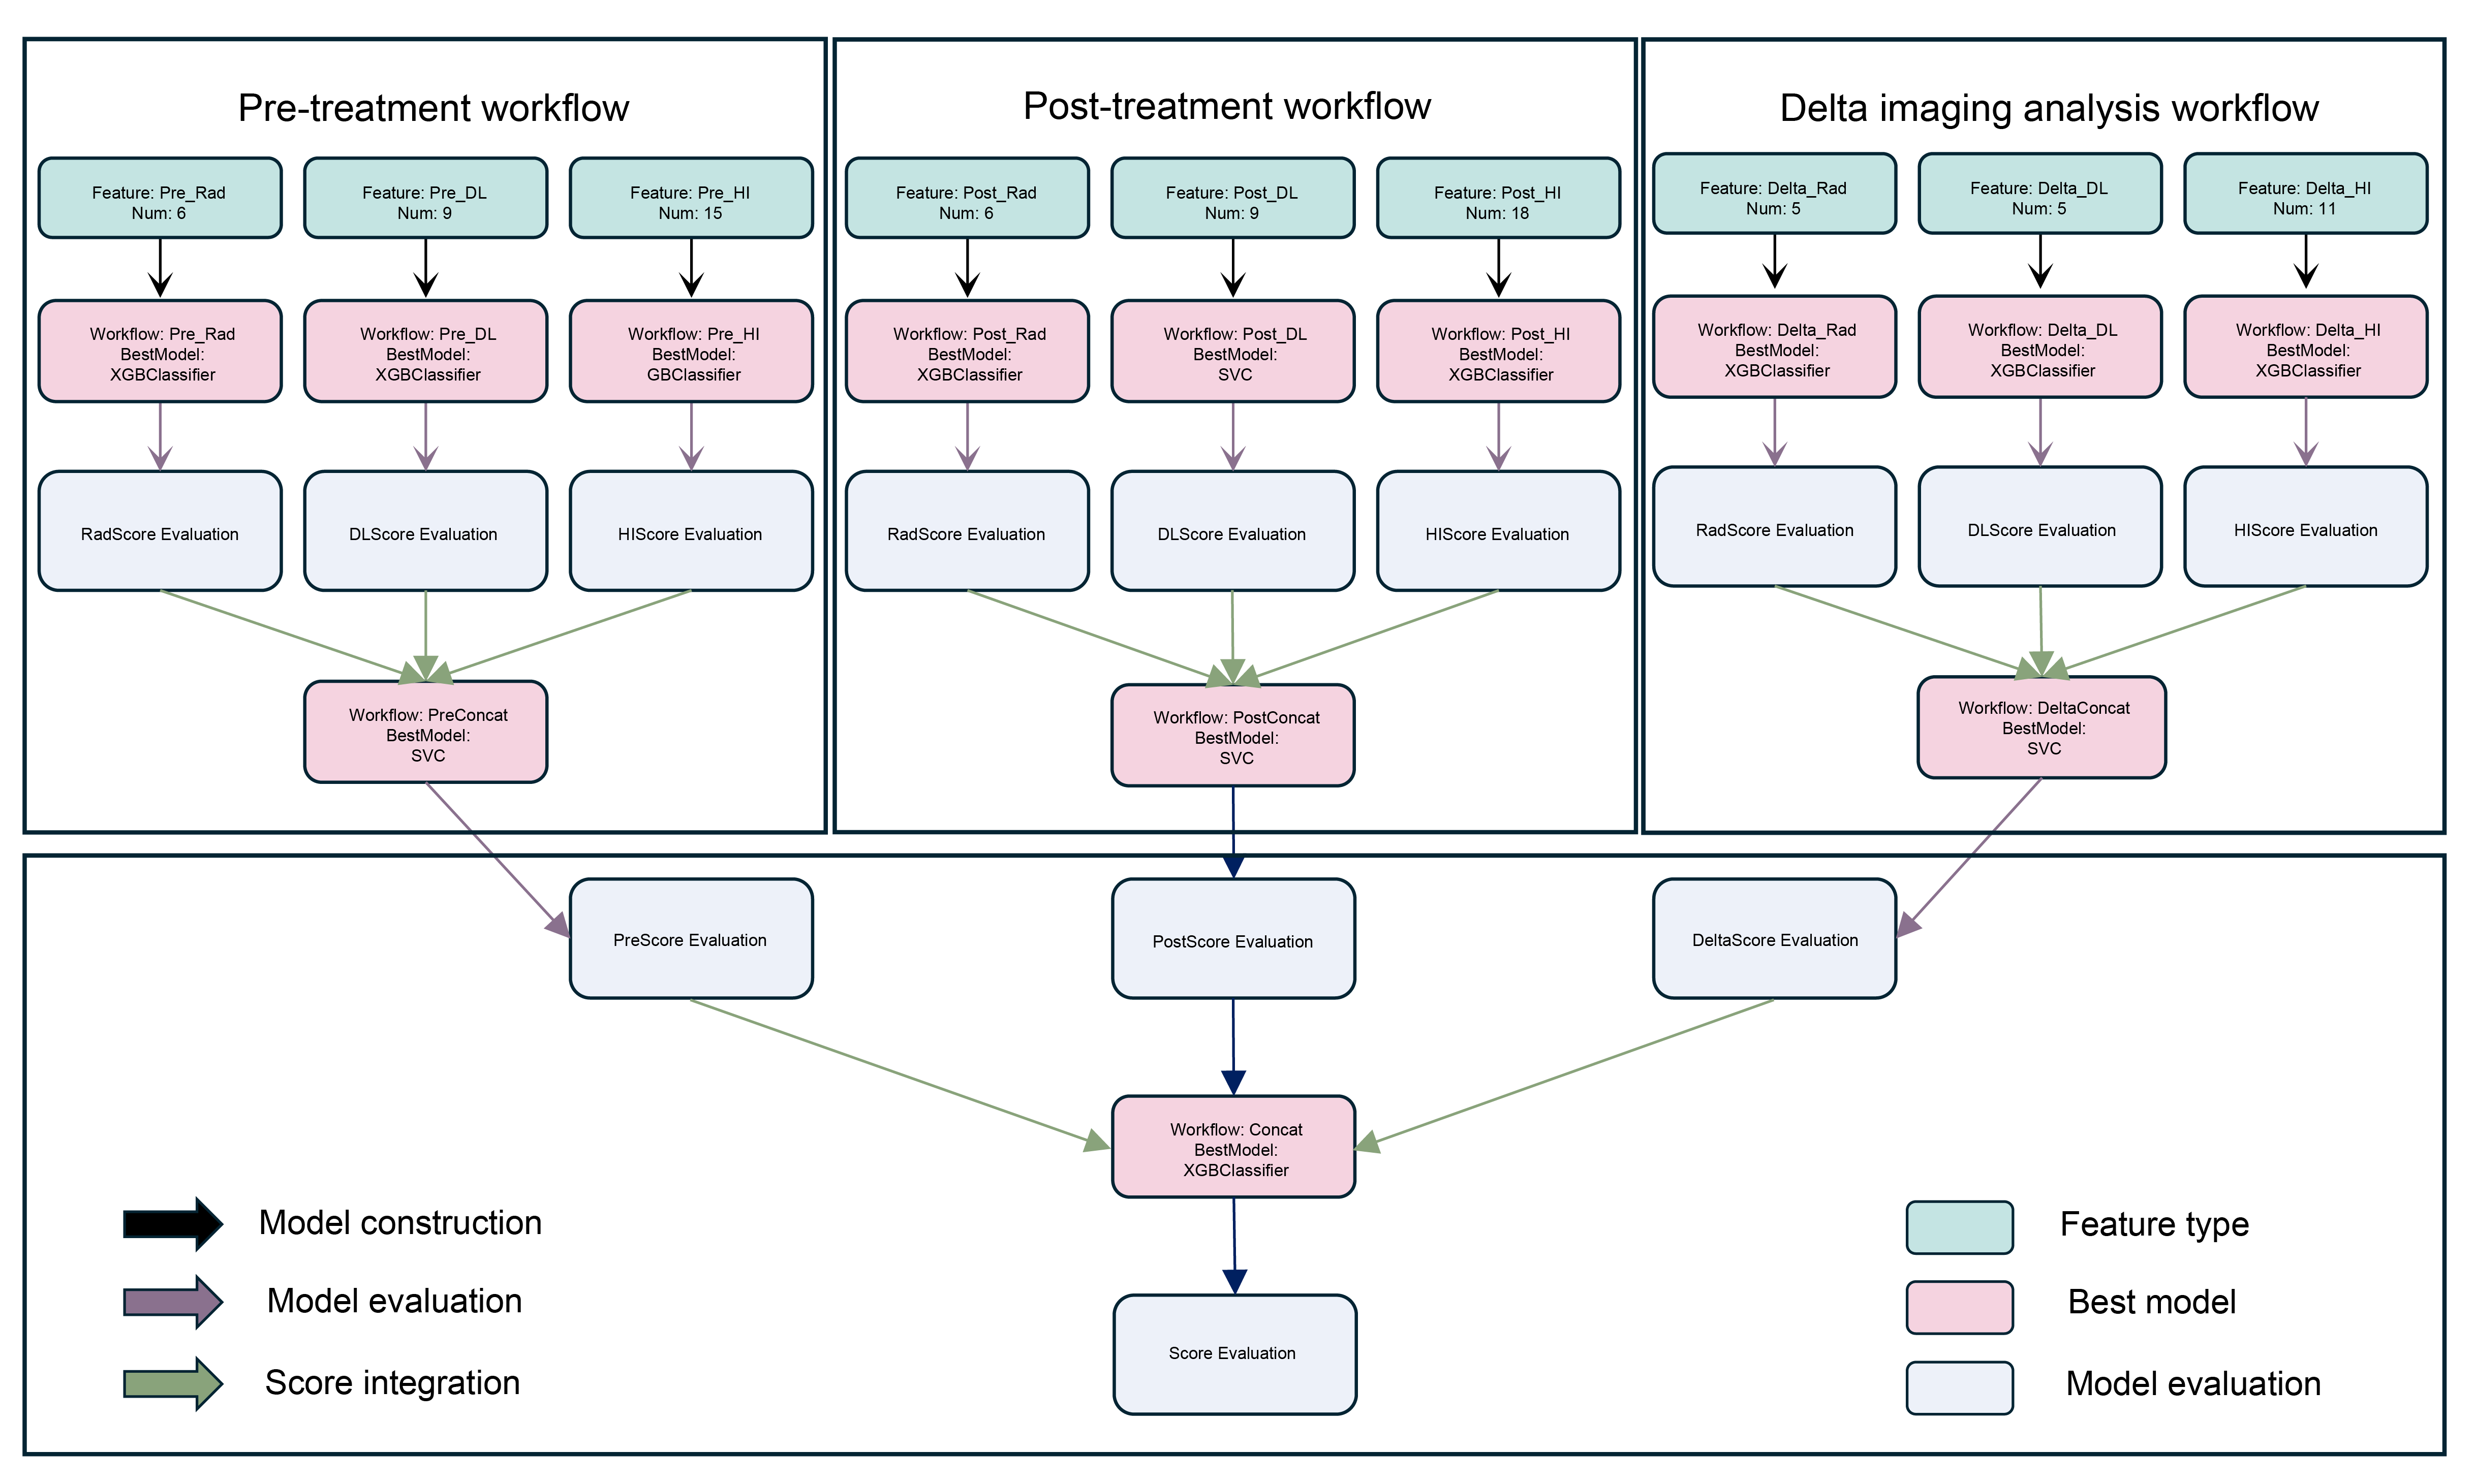

In [29]:
from IPython.display import Image
display(Image("assets/arch.png"))


### Scoring Pipeline
1. **Phase-specific Model Scoring**:
   - Process includes pre-treatment, post-treatment, and delta (change) phases
   - Each phase uses three model types: Radiomics (Rad), Deep Learning (DL), and Histogram-based (HI)
   - Individual probability scores are calculated using pre-trained models and scalers

2. **Phase Integration**:
   - For each phase (pre/post/delta), scores from all three models are combined
   - A phase-specific ensemble model predicts the probability based on Rad, DL, and HI inputs

3. **Final Prediction**:
   - All phase-level predictions are integrated into a final prediction model
   - The final score represents the overall treatment response probability

In [30]:
all_score_dfs = {}
for phase in ["pre", "post", "delta"]:
    print(f"{phase}:")
    for type_ in ["Rad", "DL", "HI"]:
        df = all_feat[(phase, type_)].copy()
        feat = df.loc[:, df.columns[df.columns.get_loc("#EC#")+1:]]
        scaler = pickle.load(open(f"pkl/LC-NICER/{phase}_{type_}/norm.pkl", "rb"))
        model = pickle.load(open(f"pkl/LC-NICER/{phase}_{type_}/model.pkl", "rb"))
        score = model.predict_proba(scaler.transform(feat))[:, 1]
        # all_scores[(phase, type_)] = model.predict_proba(scaler.transform(feat))[:, 1]

        sdf = df.copy()
        sdf.drop(columns=feat.columns.tolist() + ["#EC#"], inplace=True)
        sdf["Probability"] = score
        all_score_dfs[(phase, type_)] = sdf
        print(f"\t{type_}:", feat.shape[1], "→", type(model))
        del df, feat, scaler, model, score

for phase in ["pre", "post", "delta"]:
    scaler = pickle.load(open(f"pkl/LC-NICER/{phase}/norm.pkl", "rb"))
    model = pickle.load(open(f"pkl/LC-NICER/{phase}/model.pkl", "rb"))

    feat = None
    for type_ in ["Rad", "DL", "HI"]:
        sdf = all_score_dfs[(phase, type_)].copy()
        sdf.set_index("PID", inplace=True)
        sdf.rename(columns={"Probability": type_}, inplace=True)
        if feat is None:
            feat = sdf.copy()
        else:
            feat.loc[sdf.index, type_] = sdf.loc[:, type_].copy()
        del sdf
    score = model.predict_proba(scaler.transform(feat[["Rad", "DL", "HI"]].values))[:, 1]
    sdf = feat.copy()
    sdf["Probability"] = score
    all_score_dfs[phase] = sdf
    print(f"{phase}:\n\t", type(model))


scaler = pickle.load(open(f"pkl/LC-NICER/final/norm.pkl", "rb"))
model = pickle.load(open(f"pkl/LC-NICER/final/model.pkl", "rb"))

feat = None
for phase in ["pre", "post", "delta"]:
    sdf = all_score_dfs[phase].copy()
    sdf.rename(columns={"Probability": phase}, inplace=True)
    if feat is None:
        feat = sdf.copy()
    else:
        feat.loc[sdf.index, phase] = sdf.loc[:, phase].copy()
    del sdf
score = model.predict_proba(scaler.transform(feat[["pre", "post", "delta"]].values))[:, 1]
sdf = feat.copy()
sdf["final"] = score
all_score_dfs["final"] = sdf

print(f"final:\n\t", type(model))

pre:
	Rad: 6 → <class 'xgboost.sklearn.XGBClassifier'>
	DL: 9 → <class 'xgboost.sklearn.XGBClassifier'>
	HI: 15 → <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>
post:
	Rad: 6 → <class 'xgboost.sklearn.XGBClassifier'>
	DL: 9 → <class 'sklearn.svm._classes.SVC'>
	HI: 18 → <class 'xgboost.sklearn.XGBClassifier'>
delta:
	Rad: 5 → <class 'xgboost.sklearn.XGBClassifier'>
	DL: 5 → <class 'xgboost.sklearn.XGBClassifier'>
	HI: 11 → <class 'xgboost.sklearn.XGBClassifier'>
pre:
	 <class 'sklearn.svm._classes.SVC'>
post:
	 <class 'sklearn.svm._classes.SVC'>
delta:
	 <class 'sklearn.svm._classes.SVC'>
final:
	 <class 'xgboost.sklearn.XGBClassifier'>


# Results

In [31]:
all_score_dfs["final"]

,ID,Rad,DL,HI,pre,post,delta,final
PID,,,,,,,,
P1,demo_pre_P1,0.309029,0.428504,0.376176,0.351508,0.429286,0.352307,0.185097
P2,demo_pre_P2,0.478069,0.347796,0.389560,0.476686,0.709486,0.810199,0.926989


# Visualization

In [32]:
import SimpleITK as sitk
import numpy as np
from skimage.color import label2rgb
import matplotlib.pyplot as plt

def plot_multilabel_overlay(img_slice, mask_slice, alpha=0.3):
    img_normalized = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min())
        
    overlay = label2rgb(mask_slice, 
                       image=img_normalized,
                       alpha=alpha,
                       bg_label=0,
                       kind='overlay')
    
    fig = plt.figure(figsize=(3, 3))
    plt.imshow(overlay)
    plt.axis('off')
    plt.tight_layout()
    
    plt.close()
    
    return fig

def combine_figs(figs, titles=["tumor", "peritumor#3", "peritumor#5", "peritumor#7"]):
    fig_combined = plt.figure(figsize=(12, 3))  
    
    for idx, (fig, title) in enumerate(zip(figs, titles), 1):
        ax = fig_combined.add_subplot(1, 4, idx)
        
        orig_ax = fig.axes[0]
        img = orig_ax.images[0]
        
        ax.imshow(img.get_array())
        ax.set_title(title)
        ax.axis('off')
    
    plt.tight_layout()
    
    for fig in figs:
        plt.close(fig)
    plt.close()
        
    return fig_combined

## VariousMask

In [33]:
varm_state

{'Step': 'VariousMask',
 'Datasets': {'peritumor#3#lung': {'type': 'testing',
   'path': 'output/test/VariousMask/lung/peritumor#3.csv'},
  'peritumor#5#lung': {'type': 'testing',
   'path': 'output/test/VariousMask/lung/peritumor#5.csv'},
  'peritumor#7#lung': {'type': 'testing',
   'path': 'output/test/VariousMask/lung/peritumor#7.csv'},
  'tumor#lung': {'type': 'testing',
   'path': 'output/test/VariousMask/lung/tumor.csv'}}}

In [34]:
df = pd.read_csv(varm_state["Datasets"]["tumor#lung"]["path"])
df

,ID,PID,phase,image_path,mask_path
0,demo_pre_P1,P1,pre,image/DT60508.nii.gz,mask/tumor/DT60508.nii.gz
1,demo_post_P1,P1,post,image/T5179839.nii.gz,mask/tumor/T5179839.nii.gz
2,demo_pre_P2,P2,pre,image/DT89646.nii.gz,mask/tumor/DT89646.nii.gz
3,demo_post_P2,P2,post,image/DT192542.nii.gz,mask/tumor/DT192542.nii.gz


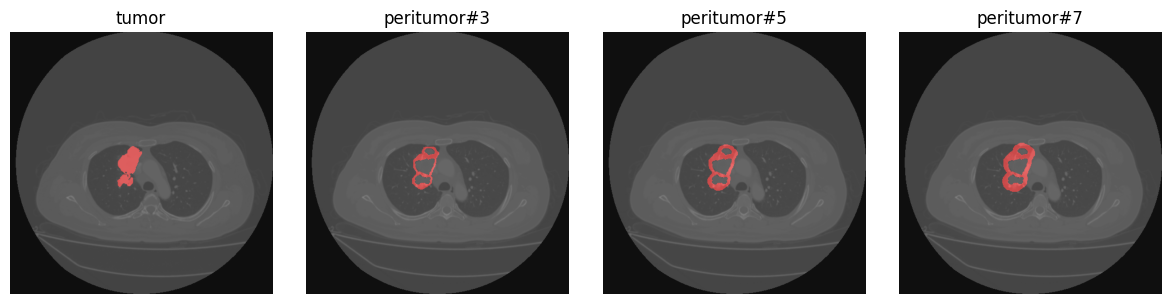

In [35]:
base_dir = output_dir / "VariousMask" / "lung"
img_np = sitk.GetArrayFromImage(sitk.ReadImage(base_dir / "image/DT60508.nii.gz"))

figs = []
for type_ in ["tumor", "peritumor#3", "peritumor#5", "peritumor#7"]:
    mask_np = sitk.GetArrayFromImage(sitk.ReadImage(base_dir / "mask" / type_ / "DT60508.nii.gz"))
    pixels_per_slice = np.sum(mask_np > 0, axis=(1, 2))
    slice_idx = np.argmax(pixels_per_slice)
    fig = plot_multilabel_overlay(img_np[slice_idx], mask_np[slice_idx], alpha=0.5)
    figs.append(fig)
combine_figs(figs)

## PreSegmentation

In [36]:
seg_state

{'Step': 'PreSegmentation',
 'Datasets': {'peritumor#3#lung': {'type': 'testing',
   'path': 'output/test/PreSegmentation/peritumor#3#lung/peritumor#3.csv'},
  'peritumor#5#lung': {'type': 'testing',
   'path': 'output/test/PreSegmentation/peritumor#5#lung/peritumor#5.csv'},
  'peritumor#7#lung': {'type': 'testing',
   'path': 'output/test/PreSegmentation/peritumor#7#lung/peritumor#7.csv'},
  'tumor#lung': {'type': 'testing',
   'path': 'output/test/PreSegmentation/tumor#lung/tumor.csv'}}}

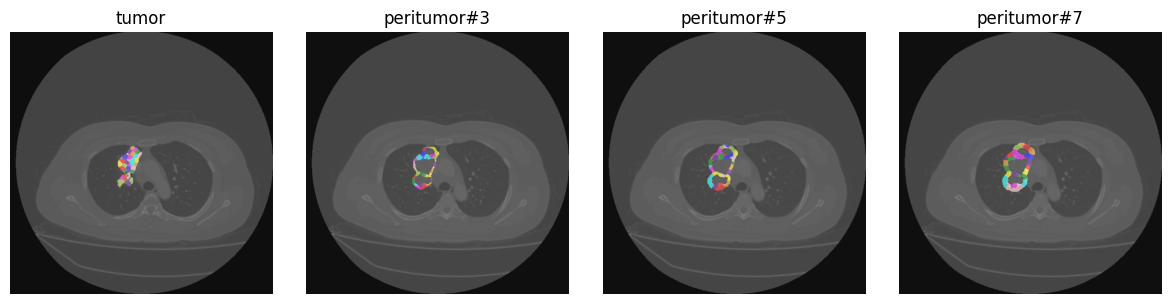

In [37]:
base_dir = output_dir / "PreSegmentation"

figs = []
for type_ in ["tumor", "peritumor#3", "peritumor#5", "peritumor#7"]:
    img_np = sitk.GetArrayFromImage(sitk.ReadImage(base_dir / f"{type_}#lung//image/DT60508.nii.gz"))
    mask_np = sitk.GetArrayFromImage(sitk.ReadImage(base_dir / f"{type_}#lung/mask/{type_}/DT60508.nii.gz"))
    pixels_per_slice = np.sum(mask_np > 0, axis=(1, 2))
    slice_idx = np.argmax(pixels_per_slice)
    fig = plot_multilabel_overlay(img_np[slice_idx], mask_np[slice_idx], alpha=0.5)
    figs.append(fig)
combine_figs(figs)

## SubRegions

In [38]:
sr_state

{'Step': 'SubRegionClustering',
 'Datasets': {'peritumor#3#lung': {'type': 'testing',
   'path': 'output/test/SubRegionClustering/peritumor#3#lung/peritumor#3#lung.csv'},
  'peritumor#5#lung': {'type': 'testing',
   'path': 'output/test/SubRegionClustering/peritumor#5#lung/peritumor#5#lung.csv'},
  'peritumor#7#lung': {'type': 'testing',
   'path': 'output/test/SubRegionClustering/peritumor#7#lung/peritumor#7#lung.csv'},
  'tumor#lung': {'type': 'testing',
   'path': 'output/test/SubRegionClustering/tumor#lung/tumor#lung.csv'}}}

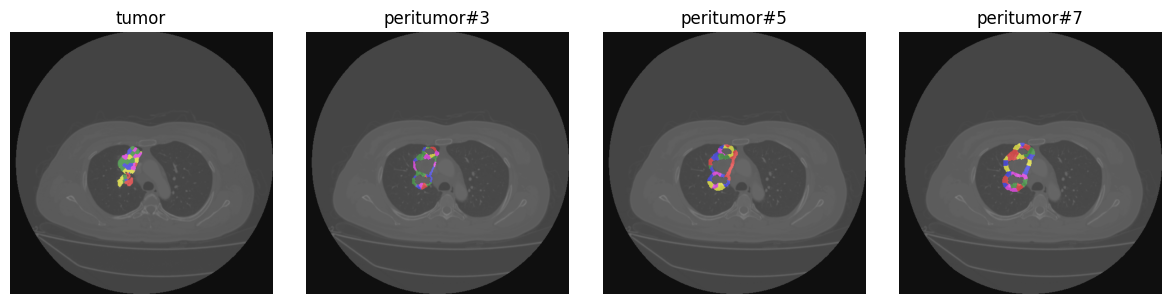

In [39]:
base_dir = output_dir / "SubRegionClustering"

figs = []
for type_ in ["tumor", "peritumor#3", "peritumor#5", "peritumor#7"]:
    img_np = sitk.GetArrayFromImage(sitk.ReadImage(base_dir / f"{type_}#lung//image/DT60508.nii.gz"))
    mask_np = sitk.GetArrayFromImage(sitk.ReadImage(base_dir / f"{type_}#lung/mask/{type_}/DT60508.nii.gz"))
    pixels_per_slice = np.sum(mask_np > 0, axis=(1, 2))
    slice_idx = np.argmax(pixels_per_slice)
    fig = plot_multilabel_overlay(img_np[slice_idx], mask_np[slice_idx], alpha=0.5)
    figs.append(fig)
combine_figs(figs)

# Reset (Optional)

In [40]:
# for path in Path(output_dir).rglob("state.pkl"):
#     path.unlink()